# Zomato Ratings — Exploratory Data Analysis

**Goal:** figure out what actually drives a restaurant's rating on Zomato — cost, cuisine, location, online ordering, table booking — and where the biggest gaps/opportunities are.

Data: `data/processed/zomato_clean.csv` (output of `scripts/01_clean_zomato.py`)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

df = pd.read_csv("../data/processed/zomato_clean.csv")
print(df.shape)
df.head()


(9215, 15)


,name,online_order,book_table,rate,votes,location,rest_type,dish_liked,cuisines,cost_for_two,reviews_list,listing_type,listing_city,review_count_parsed,review_text_combined
0,Byg Brewski Brewing Company,1,1,4.9,16832,Sarjapur Road,Microbrewery,"Cocktails, Butter Chicken, Dahi Kebab, Rajma C...","Continental, North Indian, Italian, South Indi...",1600.0,"[('Rated 5.0', ""RATED\n This is an absolute g...",Delivery,Sarjapur Road,639,This is an absolute great place. The service i...
1,Toit,0,0,4.7,14956,Indiranagar,Microbrewery,"Beer, Pesto Pizza, Nachos, Cocktails, Beef Las...","Italian, American, Pizza",1500.0,"[('Rated 4.0', ""RATED\n The crowd keeps flowi...",Drinks & nightlife,Indiranagar,71,The crowd keeps flowing in and out at Toit. It...
2,Truffles,0,0,4.7,14726,Koramangala 5th Block,"Cafe, Casual Dining","Burgers, Pasta, Cocktails, American Cheese Bur...","Cafe, American, Burger, Steak",900.0,"[('Rated 3.0', ""RATED\n Not bad but the burge...",Dine-out,Koramangala 7th Block,424,Not bad but the burgers didn't match my expect...
3,Ab'S - Absolute Barbecues,0,1,4.8,12121,Marathahalli,Casual Dining,"Raj Kachori, Paan Kulfi, Churros, Butter Chick...","European, Mediterranean, North Indian, BBQ",1600.0,"[('Rated 4.0', 'RATED\n We came here for a te...",Buffet,Marathahalli,266,We came here for a team dinner. Quite big plac...
4,The Black Pearl,0,1,4.7,10550,Koramangala 5th Block,"Casual Dining, Bar","Chocolate Lollipop, Chocolate Biscuit, Fire Sh...","North Indian, European, Mediterranean",1400.0,"[('Rated 5.0', 'RATED\n Amazing experience am...",Pubs and bars,Koramangala 7th Block,415,Amazing experience amazing food. I have never ...


In [2]:
# Deduplicate to restaurant-level: keep the row with the highest votes 
# per (name, location) — this is the most complete/current snapshot
df_restaurant_level = (
    df.sort_values("votes", ascending=False)
    .drop_duplicates(subset=["name", "location"], keep="first")
)

print(f"Before dedup: {len(df):,} rows")
print(f"After dedup to restaurant-level: {len(df_restaurant_level):,} unique restaurants")

Before dedup: 9,215 rows
After dedup to restaurant-level: 9,215 unique restaurants


## 1. Overall rating distribution
How are ratings spread out? Are most restaurants clustered around a certain score?

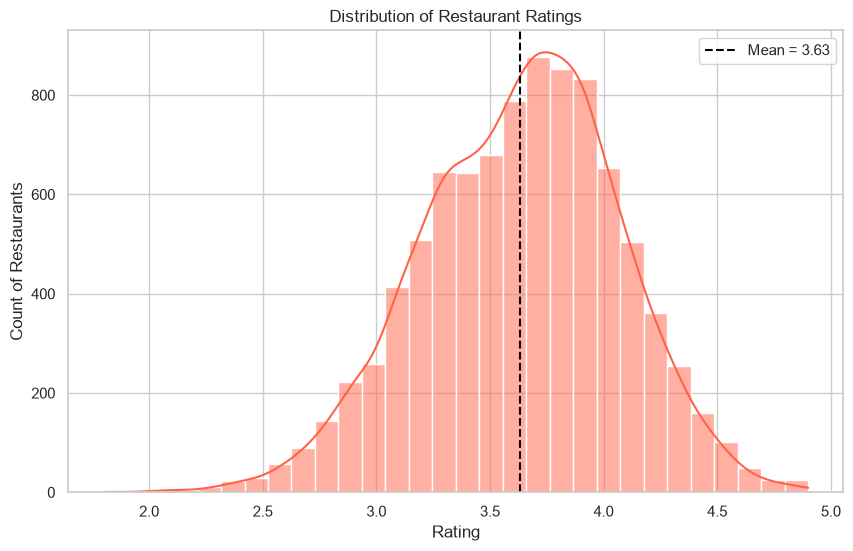

count    9215.000000
mean        3.631264
std         0.430300
min         1.800000
25%         3.300000
50%         3.700000
75%         3.900000
max         4.900000
Name: rate, dtype: float64


In [3]:
plt.figure(figsize=(10, 6))
sns.histplot(df_restaurant_level["rate"], bins=30, kde=True, color="tomato")
plt.title("Distribution of Restaurant Ratings")
plt.xlabel("Rating")
plt.ylabel("Count of Restaurants")
plt.axvline(df_restaurant_level["rate"].mean(), color="black", linestyle="--", label=f"Mean = {df_restaurant_level['rate'].mean():.2f}")
plt.legend()
plt.show()

print(df_restaurant_level["rate"].describe())


## 2. Does cost actually drive rating?
Common assumption: more expensive = better rated. Let's test it.

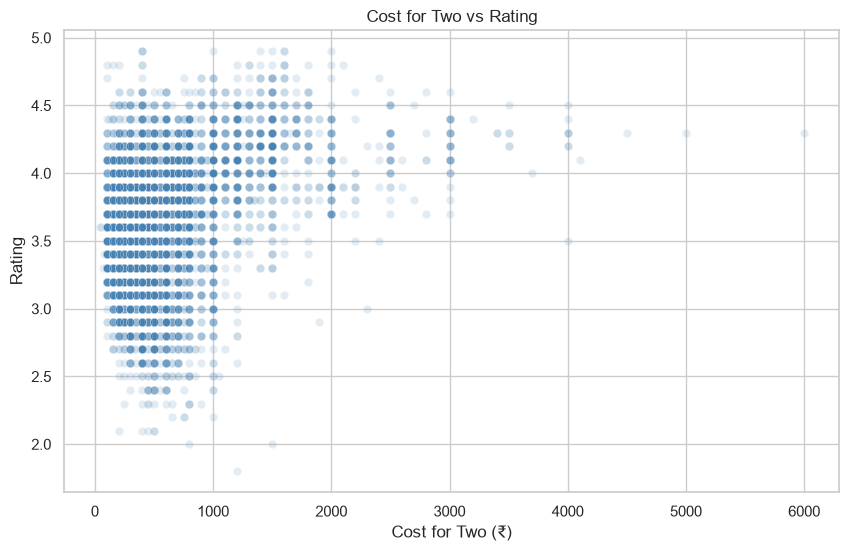

Correlation between cost and rating: 0.334


In [4]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_restaurant_level, x="cost_for_two", y="rate", alpha=0.15, color="steelblue")
plt.title("Cost for Two vs Rating")
plt.xlabel("Cost for Two (₹)")
plt.ylabel("Rating")
plt.show()

corr = df_restaurant_level[["cost_for_two", "rate"]].corr().iloc[0, 1]
print(f"Correlation between cost and rating: {corr:.3f}")


**Interpretation:** a correlation close to 0 means cost is barely related to rating — write down the actual number you get here, it's one of your key findings.

## 3. Online order & table booking — do they matter?
Does offering online ordering or table booking correlate with a better rating?

C:\Users\Anushka Ghat\AppData\Local\Temp\ipykernel_14140\1824077150.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_restaurant_level, x="online_order", y="rate", ax=axes[0], palette="Set2")
C:\Users\Anushka Ghat\AppData\Local\Temp\ipykernel_14140\1824077150.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels(["No", "Yes"])
C:\Users\Anushka Ghat\AppData\Local\Temp\ipykernel_14140\1824077150.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_restaurant_level, x="book_table", y="rate", ax=axes[1], palette="Set2")
C:\Users\Anushka 

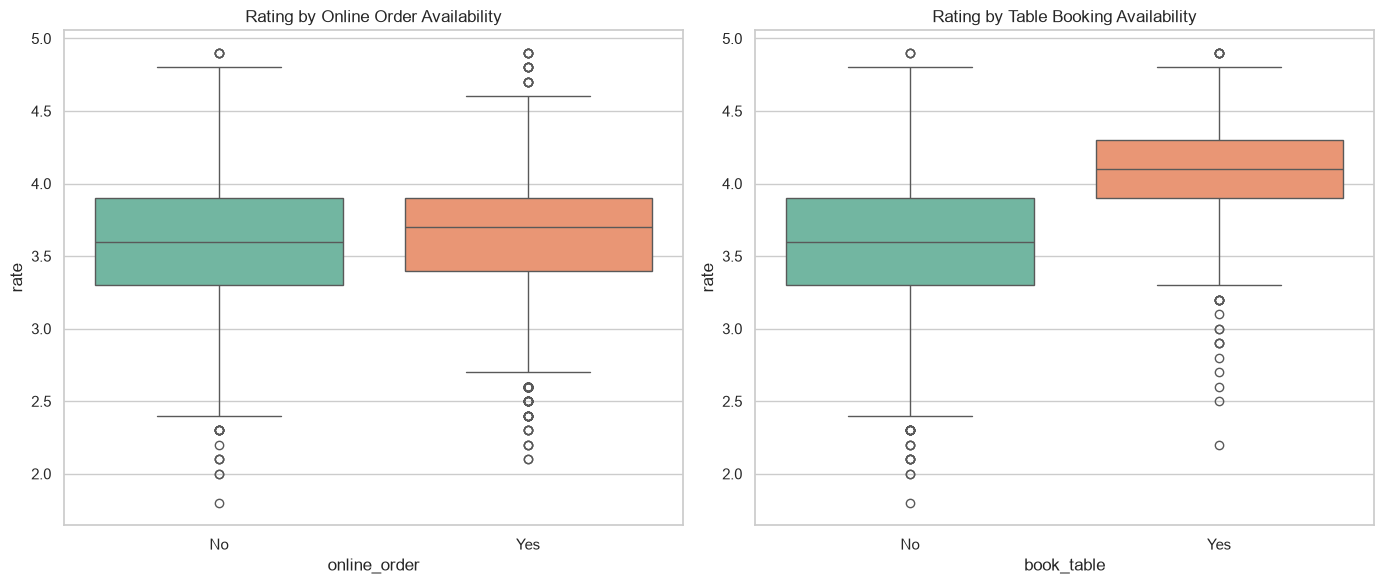

online_order
0    3.591016
1    3.657543
Name: rate, dtype: float64
book_table
0    3.576919
1    4.114823
Name: rate, dtype: float64


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.boxplot(data=df_restaurant_level, x="online_order", y="rate", ax=axes[0], palette="Set2")
axes[0].set_xticklabels(["No", "Yes"])
axes[0].set_title("Rating by Online Order Availability")

sns.boxplot(data=df_restaurant_level, x="book_table", y="rate", ax=axes[1], palette="Set2")
axes[1].set_xticklabels(["No", "Yes"])
axes[1].set_title("Rating by Table Booking Availability")

plt.tight_layout()
plt.show()

print(df_restaurant_level.groupby("online_order")["rate"].mean())
print(df_restaurant_level.groupby("book_table")["rate"].mean())


## 4. Top cuisines — which get rated highest (with meaningful volume)?
We filter to cuisines with a decent number of restaurants so we're not ranking a cuisine based on 2 outlets.

C:\Users\Anushka Ghat\AppData\Local\Temp\ipykernel_14140\2178929894.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top15["mean"], y=top15.index, palette="viridis")


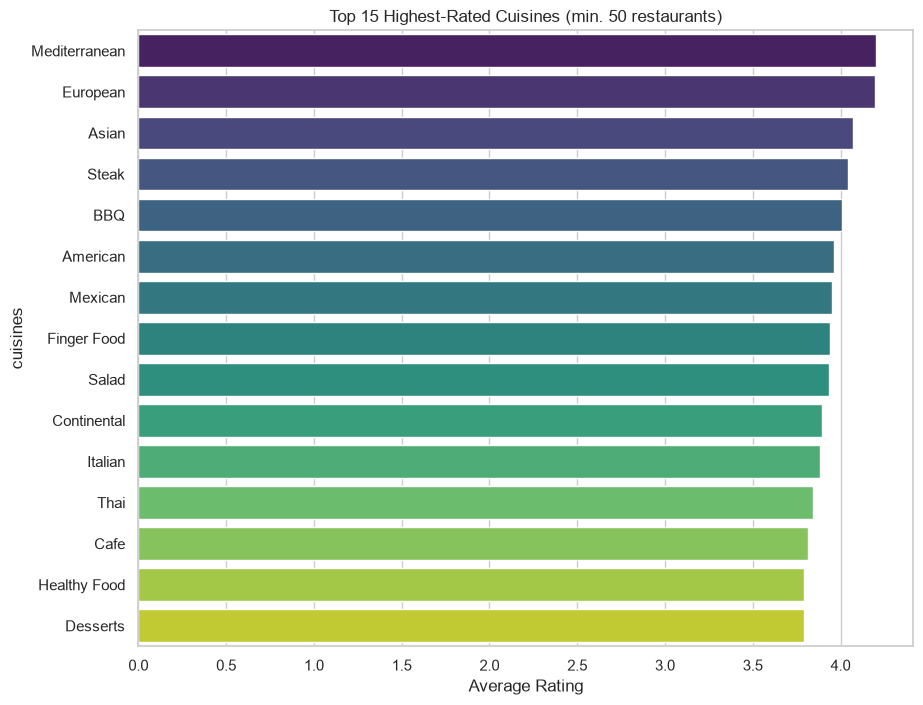

,mean,count
cuisines,,
Mediterranean,4.204651,86
European,4.195000,100
Asian,4.068020,197
Steak,4.043243,74
BBQ,4.010937,128
American,3.964500,200
Mexican,3.950505,99
Finger Food,3.941875,160
Salad,3.932164,171


In [6]:
# Explode multi-cuisine strings like "North Indian, Chinese" into separate rows
cuisine_df = df_restaurant_level.assign(cuisines=df_restaurant_level["cuisines"].str.split(",")).explode("cuisines")
cuisine_df["cuisines"] = cuisine_df["cuisines"].str.strip()

cuisine_stats = (
    cuisine_df.groupby("cuisines")["rate"]
    .agg(["mean", "count"])
    .query("count >= 50")
    .sort_values("mean", ascending=False)
)

top15 = cuisine_stats.head(15)

plt.figure(figsize=(10, 8))
sns.barplot(x=top15["mean"], y=top15.index, palette="viridis")
plt.title("Top 15 Highest-Rated Cuisines (min. 50 restaurants)")
plt.xlabel("Average Rating")
plt.show()

top15


## 5. Location analysis — which Bangalore localities rate highest?
Same filtering logic: only localities with a meaningful restaurant count.

C:\Users\Anushka Ghat\AppData\Local\Temp\ipykernel_14140\1861230100.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_locations["mean"], y=top_locations.index, palette="mako")


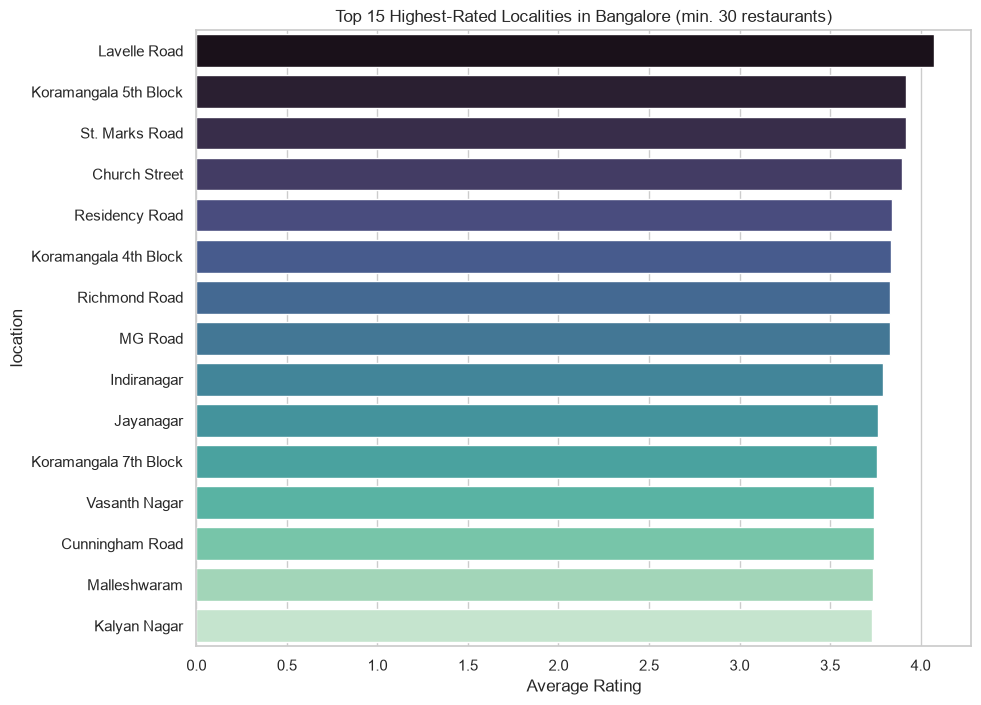

,mean,count
location,,
Lavelle Road,4.076923,52
Koramangala 5th Block,3.920417,240
St. Marks Road,3.917647,34
Church Street,3.898148,54
Residency Road,3.839726,73
Koramangala 4th Block,3.835577,104
Richmond Road,3.831343,67
MG Road,3.829268,82
Indiranagar,3.793349,436


In [7]:
location_stats = (
    df_restaurant_level.groupby("location")["rate"]
    .agg(["mean", "count"])
    .query("count >= 30")
    .sort_values("mean", ascending=False)
)

top_locations = location_stats.head(15)

plt.figure(figsize=(10, 8))
sns.barplot(x=top_locations["mean"], y=top_locations.index, palette="mako")
plt.title("Top 15 Highest-Rated Localities in Bangalore (min. 30 restaurants)")
plt.xlabel("Average Rating")
plt.show()

top_locations


## 6. The complaint signal: high votes, low rating
Restaurants with lots of votes but a low rating are a strong signal of a real, well-known service/quality problem — not just an unlucky one-off review.

In [8]:
problem_restaurants = df_restaurant_level[(df["votes"] > df_restaurant_level["votes"].quantile(0.75)) & (df_restaurant_level["rate"] < 3.5)]
problem_restaurants = problem_restaurants.sort_values("votes", ascending=False)

print(f"Found {len(problem_restaurants)} restaurants with high visibility but low ratings")
problem_restaurants[["name", "location", "rate", "votes", "cost_for_two", "cuisines"]].head(20)


Found 218 restaurants with high visibility but low ratings


,name,location,rate,votes,cost_for_two,cuisines
219,Moriz Restaurant,Brookefield,2.8,1884,750.0,"Arabian, North Indian, Biryani, Chinese, Seafood"
332,Moriz Restaurant,Electronic City,3.1,1365,700.0,"Arabian, Seafood, North Indian, Chinese, BBQ, ..."
527,Delhi Food Point,Koramangala 1st Block,3.3,912,250.0,"North Indian, Beverages"
529,Lazeez,Koramangala 5th Block,3.1,911,600.0,"North Indian, Mughlai, Biryani"
592,Freshmenu,Whitefield,3.2,835,450.0,"Healthy Food, Chinese, Biryani, North Indian, ..."
594,Savoury Restaurant,Sarjapur Road,2.9,833,800.0,"Arabian, North Indian, Chinese, Kerala, Seafoo..."
619,M.M.A. Kabab'S & Biriyani Center,Brookefield,3.3,802,400.0,"Arabian, Mughlai, Chinese, Kebab, Fast Food"
724,Biriyani Nights,New BEL Road,3.2,713,500.0,"Biryani, Kebab, Continental"
755,Moriz Restaurant,Marathahalli,3.2,684,800.0,"Arabian, North Indian, Seafood, Chinese, Biryani"
785,Kfc,Indiranagar,3.1,668,450.0,"Burger, Fast Food"


In [9]:
# Check for duplicate/near-duplicate restaurants
dupe_check = df.groupby(["name", "location"]).size().sort_values(ascending=False)
print("Restaurants appearing more than once (same name + location):")
print(dupe_check[dupe_check > 1].head(20))
print(f"\nTotal duplicate 'entries' (name+location combos appearing 2+ times): {(dupe_check > 1).sum()}")
print(f"Total rows these duplicates account for: {dupe_check[dupe_check > 1].sum()}")

Restaurants appearing more than once (same name + location):
Series([], dtype: int64)

Total duplicate 'entries' (name+location combos appearing 2+ times): 0
Total rows these duplicates account for: 0


In [10]:
# Check if listing_type explains the duplication
sample = df[(df["name"] == "Hammered") & (df["location"] == "Cunningham Road")]
print(sample[["name", "location", "listing_type", "rate", "votes"]].head(10))
print(f"\nUnique listing_type values overall: {df['listing_type'].unique()}")

        name         location        listing_type  rate  votes
34  Hammered  Cunningham Road  Drinks & nightlife   4.7   4845

Unique listing_type values overall: <StringArray>
[          'Delivery', 'Drinks & nightlife',           'Dine-out',
             'Buffet',      'Pubs and bars',           'Desserts',
              'Cafes']
Length: 7, dtype: str


## 7. Feature correlation heatmap
Quick check across all numeric features at once.

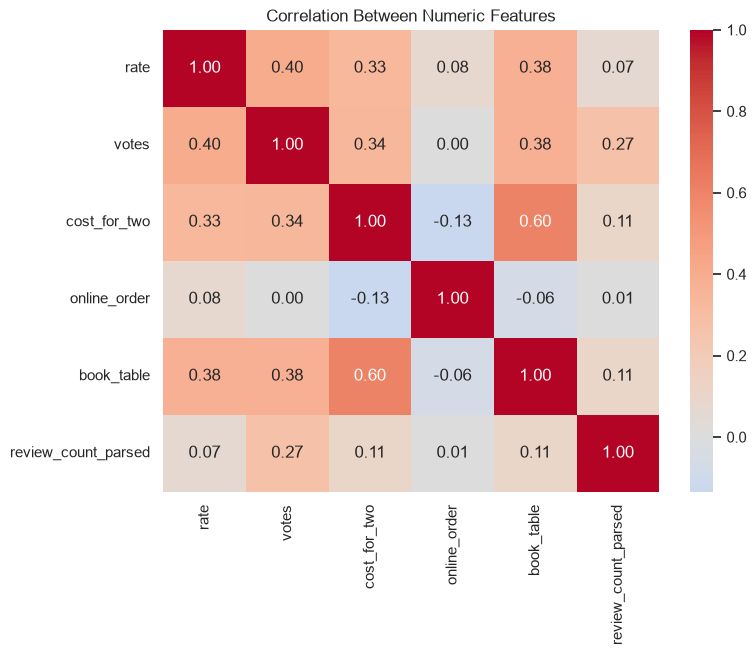

In [11]:
numeric_cols = ["rate", "votes", "cost_for_two", "online_order", "book_table", "review_count_parsed"]

plt.figure(figsize=(8, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlation Between Numeric Features")
plt.show()


## Summary of findings
*(Fill this in once you've run the notebook and seen your actual numbers — this section is what you'll quote in your LinkedIn post and README.)*

- Overall rating distribution: ...
- Cost vs rating correlation: ...
- Online order / table booking effect: ...
- Top cuisines: ...
- Top localities: ...
- Number of "high-votes, low-rating" problem restaurants found: ...

## Next steps
- NLP on `review_text_combined` to see *why* the problem restaurants above are rated low
- Predictive model using these features to predict rating bucket
